### **EN3150 - Pattern Recognition**
#### **Learning from data and related challenges and linear models for regression**

#### ***1. Linear regression impact on outliers***

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


[-3.55727273]
3.916727272727277


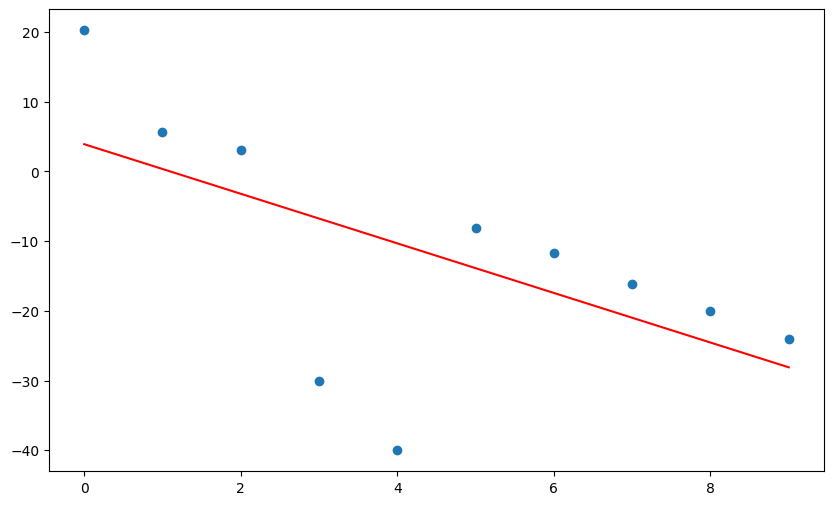

In [ ]:
data_set = pd.read_csv("dataset.csv")
data_set.index = data_set["i"]
del data_set["i"]

reg = LinearRegression().fit(data_set[["x_i"]], data_set["y_i"])
print(reg.coef_ )
print(reg.intercept_)
a, b = reg.coef_[0], reg.intercept_

plt.figure(figsize=(10,6))
plt.scatter(data_set["x_i"], data_set["y_i"], label="data")
plt.plot(data_set["x_i"], a*data_set["x_i"] + b, color = "red")
plt.show()

In [ ]:
def robust_loss(x, y, a, b, beta):
  error_sq = (y - (a*x+b))**2
  return np.mean(error_sq/(error_sq + beta**2))

beta_values = [1.0, 1e-6, 1e3]
model_1_params = {"a": -4, "b": 12}
model_2_params = {"a": a, "b": b}

print("For model 1:")
for beta in beta_values:
  loss = robust_loss(data_set["x_i"], 
                     data_set["y_i"], 
                     model_1_params["a"], 
                     model_1_params["b"], 
                     beta)
  print(f"Beta: {beta}, Loss: {loss}")

print("For model 2:")
for beta in beta_values:
  loss = robust_loss(data_set["x_i"], data_set["y_i"], model_2_params["a"], model_2_params["b"], beta)
  print(f"Beta: {beta}, Loss: {loss}")

For model 1:
Beta: 1.0, Loss: 0.435416262490386
Beta: 1e-06, Loss: 0.9999999998258206
Beta: 1000.0, Loss: 0.0002268287498440988
For model 2:
Beta: 1.0, Loss: 0.9732472128655365
Beta: 1e-06, Loss: 0.9999999999999721
Beta: 1000.0, Loss: 0.00018824604445913878


***5. What is the suitable β value to mitigate the impact of the outliers. Justify your
 answer.***

- For very small beta(1e-6), all points are treated as outliars. Therefore loss function is almost equals to 1.
- For very large beta(1e3), it reduces loss near zero. Losses are extremely small and almost indistinguishable, because even outliers are treated as tiny errors.
- For moderate beta values(1.0), At this setting, inlier errors keep most of their influence, while outliers are strongly down-weighted, mitigating their impact without discarding too much valid data.

*So, most suitable value here for beta is 1.0*

***6. Utilizing this robust estimator with selected β value, determine the most suitable
 model from the models specified in task 3 for the provided dataset. Justify your
 selection.***

Using β=1, Model 1 ($ y = -4x + 12 $) is the most suitable.  
Justification: The robust loss L(Model 1) = 0.4354 is significantly lower than L(Model 2) = 0.9728. Model 2 is the standard linear regression, heavily influenced by outliers (x=3,4), pulling the line downward (lower intercept and shallower slope) Model 1 better fits the non-outlier points. 

***7. How does this robust estimator reduce the impact of the outliers?***

The chosen robust estimator is defined as:
- ρ(e) = e² / (e² + β²),
- ρ′(e) = 2 e β² / (e² + β²)²  

For small residuals |e|, the behavior is similar to least squares (ρ(e) ≈ e²).
For large residuals |e|, the derivative decays: ρ′(e) → 0.
This means very large errors contribute almost no gradient, so outliers cannot “drag” the fit far away from the bulk of the data.
If β is set near the noise scale of the inliers, typical inlier errors are weighted normally.
Outliers with much larger residuals get strongly down-weighted.
The estimator is robust because outliers lose influence as residuals grow, ensuring the fit is dominated by the inliers.

***8. Identify another loss function that can be used for this robust estimator***

*Huber Loss Function*
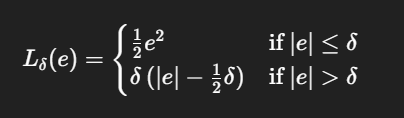

- For small residuals (∣𝑒∣≤𝛿), it behaves like the squared error (least squares), giving good efficiency for inliers.
- For large residuals (∣𝑒∣>𝛿), it grows linearly instead of quadratically, reducing the influence of outliers.

Huber loss is a robust alternative to the squared error, combining efficiency for inliers with resistance to outliers.a


#### ***2. Loss Function***

    True y=1  Predicted y       MSE       BCE
0        1.0        0.005  0.990025  5.298317
1        1.0        0.010  0.980100  4.605170
2        1.0        0.050  0.902500  2.995732
3        1.0        0.100  0.810000  2.302585
4        1.0        0.200  0.640000  1.609438
5        1.0        0.300  0.490000  1.203973
6        1.0        0.400  0.360000  0.916291
7        1.0        0.500  0.250000  0.693147
8        1.0        0.600  0.160000  0.510826
9        1.0        0.700  0.090000  0.356675
10       1.0        0.800  0.040000  0.223144
11       1.0        0.900  0.010000  0.105361
12       1.0        1.000  0.000000  0.000000


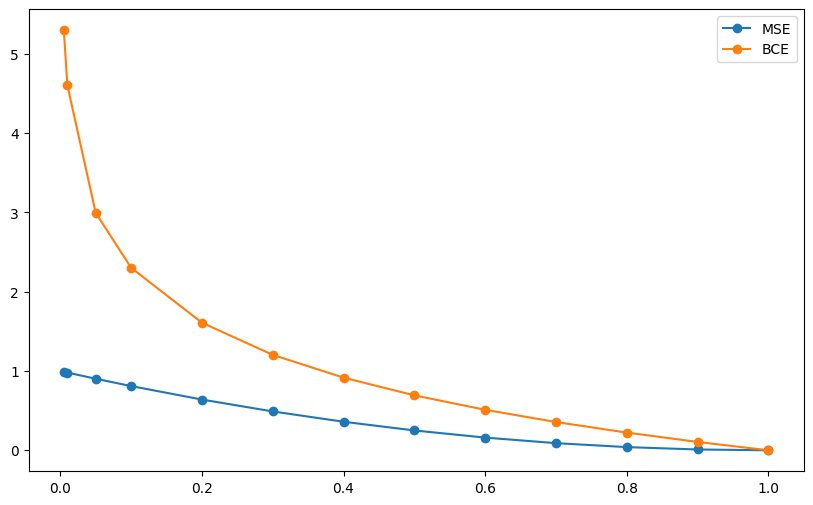

In [ ]:
y = np.ones(13)
y_p = np.array([0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def MSE(y, y_p):
  return np.mean((y-y_p)**2)

def BCE(y, y_p):
  if np.any(y_p <= 0) | np.any(y_p >= 1):
    return 0
  else:
    BCE_value = -np.mean(y*np.log(y_p) + (1-y)*np.log(1-y_p))
  return BCE_value

mse = np.zeros(len(y_p))
bce = np.zeros(len(y_p))

for i in range(len(y_p)):
  mse[i] = MSE(y, y_p[i])
  bce[i] = BCE(y, y_p[i])

table = pd.DataFrame(
  {
    "True y=1": y,
   "Predicted y": y_p,
   "MSE": mse,
   "BCE": bce
   }
)

print(table)

plt.figure(figsize=(10,6))
plt.plot(y_p, mse, label="MSE", marker="o")
plt.plot(y_p, bce, label="BCE", marker="o")
plt.legend()
plt.show()

- **Application 1:**  Better to choose MSE (Mean Square Error). It measures mean squared error between prediction and actual continous values output. Assuming Gaussian noise, minimising MSE gives the maximum likelihood estimate in regression problem

- **Application 2:** As we can see from previous example, in classification problems errors are significanly shown in the BCE loss function, that can stongly penalizes wrong predictions. So, BCE is better for classification problems.

#### ***3. Data Preprocessing***

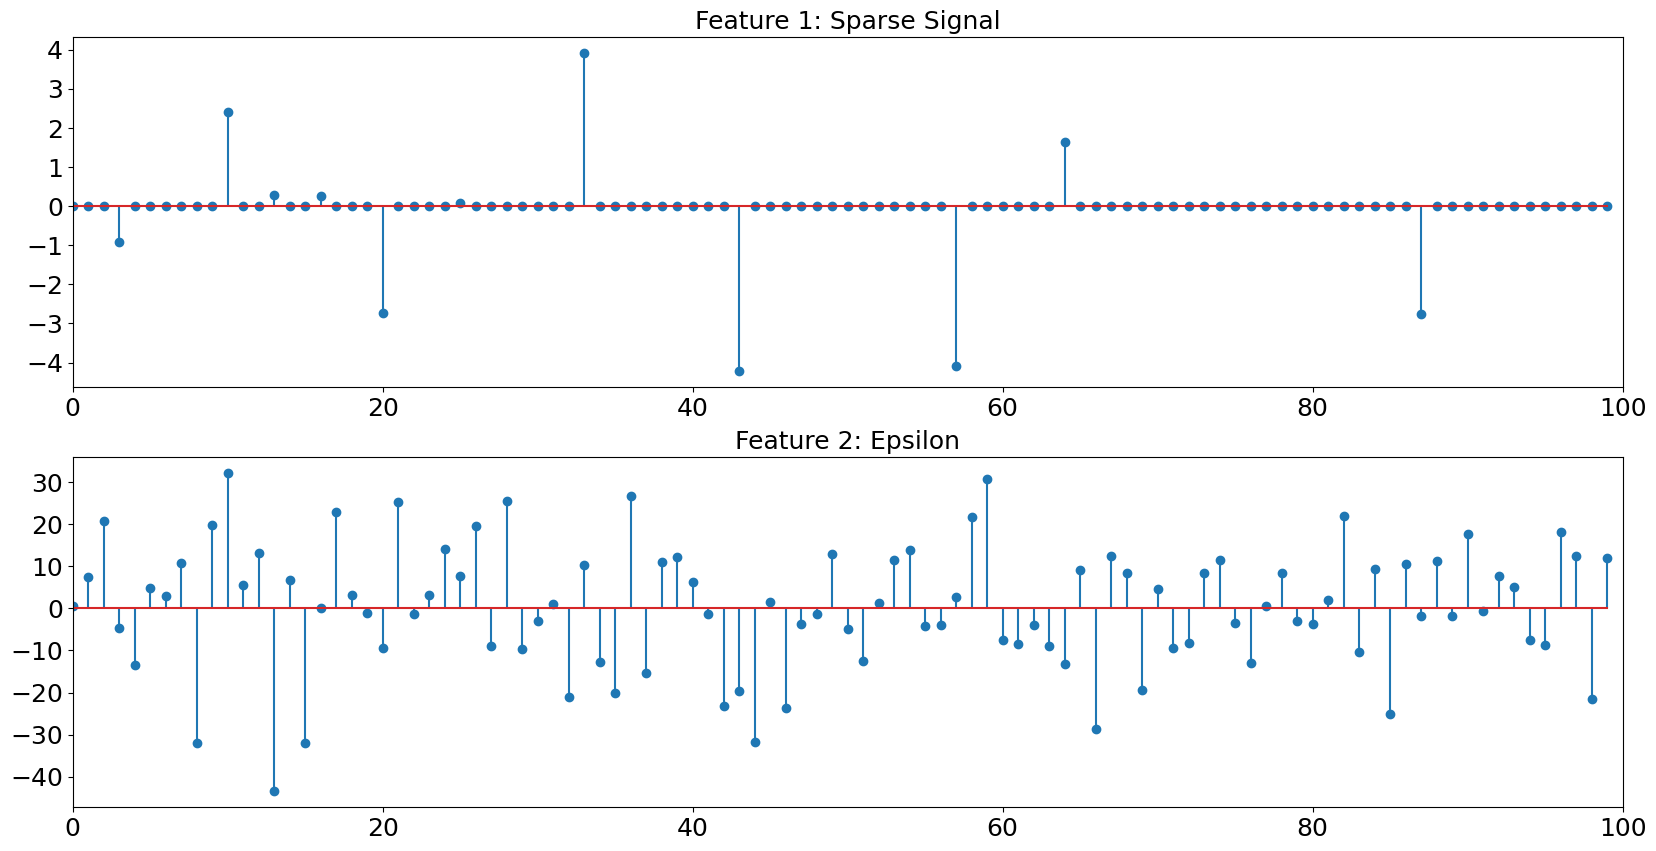

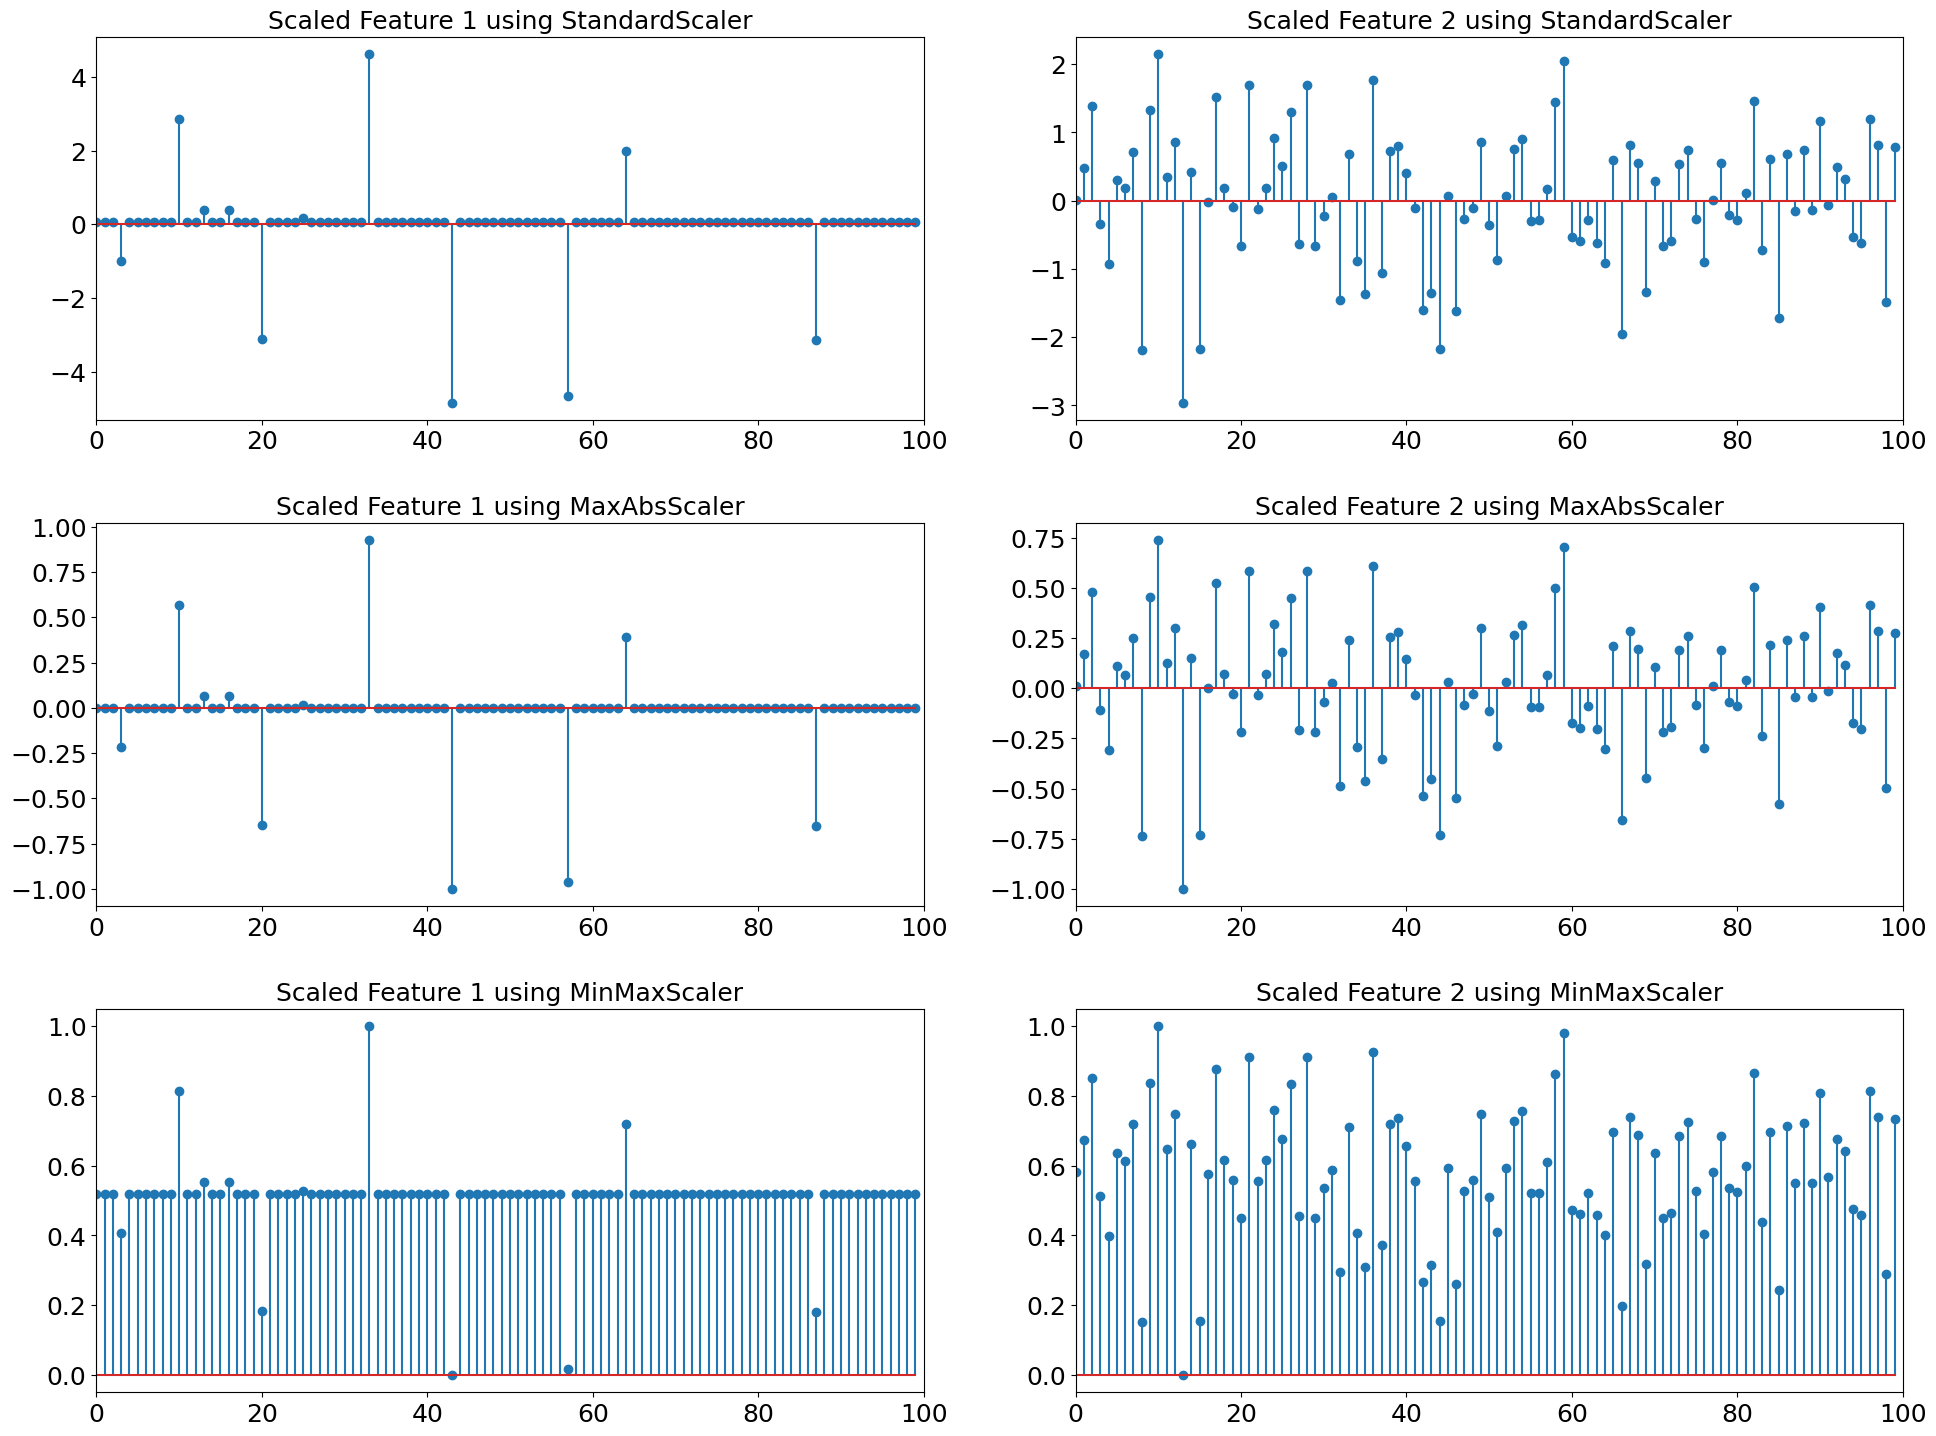

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

def generate_signal(signal_length, num_nonzero):
  signal = np.zeros(signal_length)
  nonzero_indices = np.random.choice(signal_length, num_nonzero,replace=False)
  nonzero_values = 10*np.random.randn(num_nonzero)
  signal[nonzero_indices] = nonzero_values
  return signal

signal_length = 100 # Total length of the signal
num_nonzero = 10 # Number of non-zero elements in the signal
your_index_no = 220551 # Enter your index no without english letters and without leading zeros
sparse_signal = generate_signal(signal_length, num_nonzero)
sparse_signal[10] = (your_index_no % 10)*2 + 10
if your_index_no % 10 == 0:
  sparse_signal[10] = np.random.randn(1) + 30
sparse_signal=sparse_signal/5
epsilon = np.random.normal(0, 15, signal_length )

# After generating sparse_signal and epsilon

plt.figure(figsize=(20,10))

plt.subplot(2, 1, 1)
plt.xlim(0, signal_length)
plt.title("Feature 1: Sparse Signal", fontsize=18)
plt.xticks(fontsize=18) # Adjust x-axis tick label font size
plt.yticks(fontsize=18)
plt.stem(sparse_signal)

plt.subplot(2, 1, 2)
plt.xlim(0, signal_length)
plt.title("Feature 2: Epsilon", fontsize=18)
plt.stem(epsilon)
plt.xticks(fontsize=18) # Adjust x-axis tick label font size
plt.yticks(fontsize=18)


scaler_methods = {"StandardScaler": StandardScaler(), "MaxAbsScaler": MaxAbsScaler(), "MinMaxScaler": MinMaxScaler()}

plt.figure(figsize=(20,15))
for i, (key, value) in enumerate(scaler_methods.items(), start=1):
  feature_1_scaled = value.fit_transform(sparse_signal.reshape(-1,1))
  feature_2_scaled = value.fit_transform(epsilon.reshape(-1,1))

  plt.subplot(3, 2, 2*i-1)
  plt.xlim(0, signal_length)
  plt.title(f"Scaled Feature 1 using {key}", fontsize=18)
  plt.stem(feature_1_scaled)
  plt.xticks(fontsize=18) # Adjust x-axis tick label font size
  plt.yticks(fontsize=18)

  plt.subplot(3, 2, 2*i)
  plt.xlim(0, signal_length)
  plt.title(f"Scaled Feature 2 using {key}", fontsize=18)
  plt.stem(feature_2_scaled)
  plt.xticks(fontsize=18) # Adjust x-axis tick label font size
  plt.yticks(fontsize=18)

plt.tight_layout(pad=3.0)
plt.show()

- **Feature 1:** Better scaling approach is **Max-abs scaling**.  
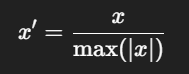  
Since the sparse signal has mostly zeros and very less non-zero values, after scaling zeros must be preserved. Max-abs scalar scales the values to the range [-1,1]

- **Feature 2:** This is dense gaussian noise. So it is better to scale with standard scalar that with zero mean and varience of 1.  
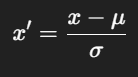  
  - 𝜇 = mean of the feature
  - 𝜎 = standard deviation of the feature